# Experimentos con Groq: Llama 3.1 8B Instant

Este notebook evalúa análisis de sentimiento financiero con `llama-3.1-8b-instant` vía Groq API.

Se ejecutan dos estrategias:

- Zero-shot
- Few-shot

Las métricas principales son `micro F1`, `macro F1` y reporte por clase.

In [1]:
!pip install -q groq pandas scikit-learn tqdm

In [2]:
import os
import time
import pandas as pd
import numpy as np

from pathlib import Path
from getpass import getpass
from groq import Groq
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix

ROOT = Path('..')

MODEL = 'llama-3.1-8b-instant'

# Cambia a un número pequeño, por ejemplo 50, para hacer una prueba rápida.
# Usa None para evaluar todo el dataset.
MAX_ROWS = None

# Pausa mínima entre llamadas para reducir errores por límite de tasa.
SLEEP_SECONDS = 0.05

datasets = {
    #'Sentences_AllAgree': ROOT / 'Sentences_AllAgree.csv',
    'FinTextSen_clean': ROOT / 'FinTextSen_clean.csv'
}

label_map = {
    0: 'negative',
    1: 'neutral',
    2: 'positive',
}

sentiment_to_label = {
    'negative': 0,
    'neutral': 1,
    'positive': 2,
}

## Configurar API key

El notebook busca la API key en la variable de entorno `GROQ_API_KEY`. Si no existe, la pedirá de forma interactiva.

In [3]:
groq_api_key = os.getenv('GROQ_API_KEY')

if not groq_api_key:
    groq_api_key = getpass('Ingresa tu GROQ_API_KEY: ')

client = Groq(api_key=groq_api_key)

## Cargar datasets

In [4]:
def cargar_dataset(ruta):
    df = pd.read_csv(ruta)
    df = df.dropna(subset=['sentences', 'labels']).copy()
    df['sentences'] = df['sentences'].astype(str).str.strip()
    df = df[df['sentences'] != ''].copy()
    df['labels'] = df['labels'].astype(int)
    return df.reset_index(drop=True)


dataframes = {nombre: cargar_dataset(ruta) for nombre, ruta in datasets.items()}

for nombre, df in dataframes.items():
    print(nombre, df.shape)
    display(df['labels'].value_counts().sort_index().rename(index=label_map).to_frame('registros'))

FinTextSen_clean (1680, 2)


,registros
labels,
negative,578
neutral,16
positive,1086


## Funciones de inferencia

In [5]:
def normalizar_respuesta(texto):
    texto = str(texto).lower().strip()

    if 'positive' in texto and 'negative' not in texto and 'neutral' not in texto:
        return 'positive'
    if 'negative' in texto and 'positive' not in texto and 'neutral' not in texto:
        return 'negative'
    if 'neutral' in texto and 'positive' not in texto and 'negative' not in texto:
        return 'neutral'

    primera = texto.replace('.', ' ').replace(',', ' ').split()
    if primera:
        palabra = primera[0]
        if palabra in sentiment_to_label:
            return palabra

    return 'unknown'


def construir_mensajes(sentence, ejemplos=None):
    mensajes = [
        {
            'role': 'system',
            'content': (
                'You are a financial sentiment classifier. '
                'Classify each sentence as exactly one of: positive, negative, neutral. '
                'Answer with only one word.'
            ),
        }
    ]

    if ejemplos:
        for ejemplo in ejemplos:
            mensajes.append({
                'role': 'user',
                'content': f"Sentence: {ejemplo['sentence']}\nSentiment:",
            })
            mensajes.append({
                'role': 'assistant',
                'content': ejemplo['sentiment'],
            })

    mensajes.append({
        'role': 'user',
        'content': f'Sentence: {sentence}\nSentiment:',
    })

    return mensajes


def predecir_sentimiento(sentence, ejemplos=None):
    respuesta = client.chat.completions.create(
        model=MODEL,
        messages=construir_mensajes(sentence, ejemplos=ejemplos),
        temperature=0,
        max_tokens=5,
    )

    texto = respuesta.choices[0].message.content
    return normalizar_respuesta(texto), texto

## Few-shot examples

Para few-shot se toma un ejemplo por clase desde el mismo dataset y se excluyen esos registros de la evaluación.

In [6]:
def obtener_ejemplos_few_shot(df):
    ejemplos = []
    indices = []

    for label in [2, 1, 0]:
        fila = df[df['labels'] == label].iloc[0]
        ejemplos.append({
            'sentence': fila['sentences'],
            'sentiment': label_map[label],
        })
        indices.append(fila.name)

    return ejemplos, indices


for nombre, df in dataframes.items():
    ejemplos, indices = obtener_ejemplos_few_shot(df)
    print('\n', nombre)
    for ejemplo in ejemplos:
        print(ejemplo['sentiment'], '-', ejemplo['sentence'])


 FinTextSen_clean
positive - watching for bounce tomorrow
neutral - short worked, puts up
negative - out $NFLX -.35


## Ejecutar experimentos

In [7]:
def preparar_eval_df(df, strategy, max_rows=None):
    eval_df = df.copy()
    ejemplos = None

    if strategy == 'few-shot':
        ejemplos, indices_ejemplos = obtener_ejemplos_few_shot(eval_df)
        eval_df = eval_df.drop(index=indices_ejemplos).reset_index(drop=True)

    if max_rows is not None:
        eval_df = eval_df.head(max_rows).copy()

    return eval_df, ejemplos


def ejecutar_experimento(nombre_dataset, df, strategy, max_rows=None):
    eval_df, ejemplos = preparar_eval_df(df, strategy, max_rows=max_rows)
    predicciones = []
    respuestas_raw = []

    for sentence in tqdm(eval_df['sentences'], desc=f'{nombre_dataset} | {strategy}'):
        try:
            pred, raw = predecir_sentimiento(sentence, ejemplos=ejemplos)
        except Exception as error:
            pred, raw = 'unknown', str(error)

        predicciones.append(pred)
        respuestas_raw.append(raw)

        if SLEEP_SECONDS:
            time.sleep(SLEEP_SECONDS)

    resultados = eval_df.copy()
    resultados['true_sentiment'] = resultados['labels'].map(label_map)
    resultados['predicted_sentiment'] = predicciones
    resultados['raw_response'] = respuestas_raw
    resultados['dataset'] = nombre_dataset
    resultados['strategy'] = strategy
    resultados['model'] = MODEL

    return resultados

In [8]:
resultados_experimentos = []

for nombre_dataset, df in dataframes.items():
    for strategy in ['zero-shot', 'few-shot']:
        resultados = ejecutar_experimento(
            nombre_dataset=nombre_dataset,
            df=df,
            strategy=strategy,
            max_rows=MAX_ROWS,
        )
        resultados_experimentos.append(resultados)

predicciones = pd.concat(resultados_experimentos, ignore_index=True)
predicciones.head()

FinTextSen_clean | zero-shot: 100%|██████████| 1680/1680 [1:11:44<00:00,  2.56s/it]
FinTextSen_clean | few-shot: 100%|██████████| 1677/1677 [1:17:38<00:00,  2.78s/it]


,sentences,labels,true_sentiment,predicted_sentiment,raw_response,dataset,strategy,model
0,watching for bounce tomorrow,2,positive,neutral,Neutral,FinTextSen_clean,zero-shot,llama-3.1-8b-instant
1,record number of passengers served in 2015,2,positive,neutral,Neutral,FinTextSen_clean,zero-shot,llama-3.1-8b-instant
2,out $NFLX -.35,0,negative,negative,Negative,FinTextSen_clean,zero-shot,llama-3.1-8b-instant
3,"Looking for a strong bounce, Lunchtime rally c...",2,positive,positive,Positive,FinTextSen_clean,zero-shot,llama-3.1-8b-instant
4,Very intrigued with the technology and growth ...,2,positive,positive,Positive,FinTextSen_clean,zero-shot,llama-3.1-8b-instant


## Métricas

In [9]:
def calcular_metricas(df_resultados):
    filas = []

    for (dataset, strategy), grupo in df_resultados.groupby(['dataset', 'strategy']):
        grupo_valido = grupo[grupo['predicted_sentiment'].isin(sentiment_to_label)].copy()
        y_true = grupo_valido['true_sentiment']
        y_pred = grupo_valido['predicted_sentiment']

        filas.append({
            'dataset': dataset,
            'strategy': strategy,
            'model': MODEL,
            'registros': len(grupo),
            'predicciones_validas': len(grupo_valido),
            'predicciones_unknown': int((grupo['predicted_sentiment'] == 'unknown').sum()),
            'micro_f1': f1_score(y_true, y_pred, average='micro'),
            'macro_f1': f1_score(y_true, y_pred, average='macro'),
        })

    return pd.DataFrame(filas)


metricas = calcular_metricas(predicciones)
metricas

,dataset,strategy,model,registros,predicciones_validas,predicciones_unknown,micro_f1,macro_f1
0,FinTextSen_clean,few-shot,llama-3.1-8b-instant,1677,1677,0,0.681574,0.539683
1,FinTextSen_clean,zero-shot,llama-3.1-8b-instant,1680,1677,3,0.584377,0.493782


In [10]:
for (dataset, strategy), grupo in predicciones.groupby(['dataset', 'strategy']):
    grupo_valido = grupo[grupo['predicted_sentiment'].isin(sentiment_to_label)].copy()

    print('\n' + '=' * 80)
    print(dataset, '|', strategy)
    print('=' * 80)
    print('Predicciones validas:', len(grupo_valido), 'de', len(grupo))
    print(classification_report(
        grupo_valido['true_sentiment'],
        grupo_valido['predicted_sentiment'],
        labels=['negative', 'neutral', 'positive'],
        zero_division=0,
    ))


FinTextSen_clean | few-shot
Predicciones validas: 1677 de 1677
              precision    recall  f1-score   support

    negative       0.88      0.71      0.79       577
     neutral       0.03      0.80      0.05        15
    positive       0.94      0.66      0.78      1085

    accuracy                           0.68      1677
   macro avg       0.62      0.73      0.54      1677
weighted avg       0.91      0.68      0.78      1677


FinTextSen_clean | zero-shot
Predicciones validas: 1677 de 1680
              precision    recall  f1-score   support

    negative       0.86      0.70      0.77       576
     neutral       0.02      0.81      0.04        16
    positive       0.94      0.52      0.67      1085

    accuracy                           0.58      1677
   macro avg       0.61      0.68      0.49      1677
weighted avg       0.90      0.58      0.70      1677



## Guardar resultados

In [11]:
predicciones_path = ROOT / 'resultados_groq_llama31_8b_predicciones.csv'
metricas_path = ROOT / 'resultados_groq_llama31_8b_metricas.csv'

predicciones.to_csv(predicciones_path, index=False)
metricas.to_csv(metricas_path, index=False)

print('Predicciones guardadas en:', predicciones_path)
print('Métricas guardadas en:', metricas_path)

Predicciones guardadas en: ..\resultados_groq_llama31_8b_predicciones.csv
Métricas guardadas en: ..\resultados_groq_llama31_8b_metricas.csv


## Matrices de confusión desde CSV guardado

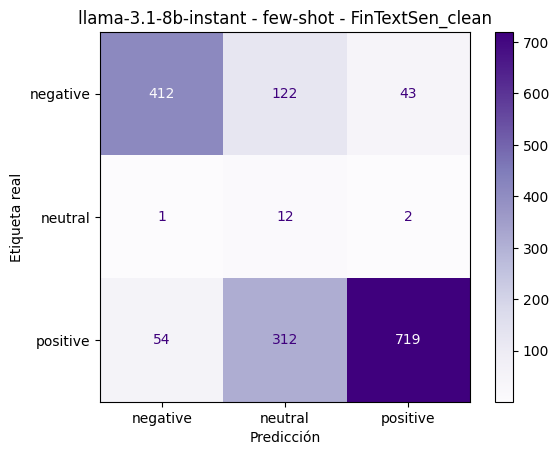

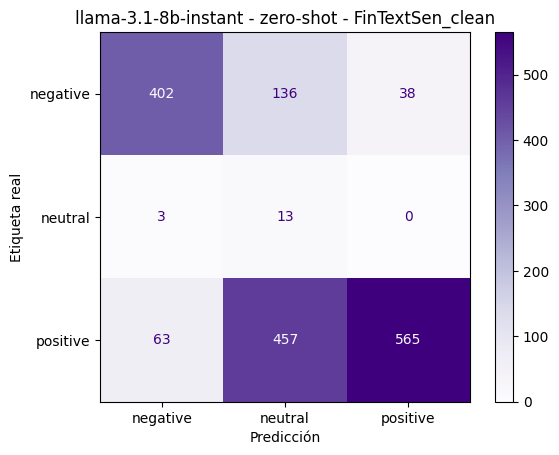

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predicciones_csv = pd.read_csv(ROOT / 'resultados_groq_llama31_8b_predicciones.csv')
orden = ['negative', 'neutral', 'positive']

for (dataset, strategy), grupo in predicciones_csv.groupby(['dataset', 'strategy']):
    grupo_valido = grupo[grupo['predicted_sentiment'].isin(orden)].copy()

    cm = confusion_matrix(
        grupo_valido['true_sentiment'],
        grupo_valido['predicted_sentiment'],
        labels=orden,
    )

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden)
    disp.plot(cmap='Purples', values_format='d')
    modelo = grupo['model'].iloc[0] if 'model' in grupo.columns else 'llama-3.1-8b-instant'
    plt.title(f'{modelo} - {strategy} - {dataset}')
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta real')
    plt.savefig(f'{modelo}_{strategy}_{dataset}_confusion_matrix.png')
    plt.show()
